# Resource estimation for the 2D Fermi-Hubbard model

This notebook estimates the cost of finding the ground-state energy of the two-dimensional
Fermi-Hubbard model by quantum phase estimation, using the plaquette Trotterization of the
time evolution.
See [`extended_hubbard.ipynb`](extended_hubbard.ipynb) for more details in model hamiltonian.

It has two halves:

1. a **logical** sweep over lattice sizes, which counts qubits, rotations, T gates and
   Toffolis in the emitted circuit; and
2. a **physical** estimate for one lattice, which maps those logical counts onto a
   fault-tolerant architecture and reports physical qubits and runtime.

## Background: the 2D Fermi-Hubbard model

The Fermi-Hubbard Hamiltonian on a square lattice is

$$
H = -t \sum_{\langle i,j \rangle, \sigma} \left( c^\dagger_{i\sigma} c_{j\sigma} + \text{h.c.} \right)
  + U \sum_i n_{i\uparrow} n_{i\downarrow},
$$

a nearest-neighbour hopping term of amplitude $t$ and an on-site repulsion $U$. 
Each site carries two spin orbitals, so an $L \times L$ lattice needs $2L^2$ qubits under the Jordan-Wigner mapping.

We take $U = 8t$, the strong-coupling regime, and a filling of $0.875$ electrons per site. The
lattice is periodic in both directions.

We allow

$$
\epsilon_{\text{total}} = 0.0051 \ \text{per site},
$$

As the lattice grows, so does the error budget. We allocate a fraction (f=2/3) to phase estimation and the remaining (1/3) to Trotter error. QRE internally allocates an error budget of (0.01) to rotation synthesis, which should be negligible for larger (L).

In [1]:
import math

import pandas as pd
from qdk import qsharp
from qdk_chemistry.algorithms import create
from qdk_chemistry.algorithms.state_preparation import identity_state_prep
from qdk_chemistry.data import AlgorithmRef, LatticeGraph, QubitOperator
from qdk_chemistry.data.qubit_operator.containers.lattice import LatticeContainer
from qdk_chemistry.utils import Logger
from qdk_chemistry.utils.qsharp import create_qsharp_context, use_qsharp_context

# Silence the library logs so the tables below stay readable.
Logger.set_global_level(Logger.LogLevel.off)

#: Hopping amplitude, which sets the unit of energy.
HOPPING_T = 1.0

#: U = 8t for the strong-coupling regime.
U_OVER_T = 8.0

#: Electrons per SITE, not per orbital.
FILLING = 0.875

#: Total error budget per site, covering phase estimation, Trotter and gate synthesis.
TARGET_PRECISION_PER_SITE = 0.0051

#: Number of phase qubits in QPE.
QPE_PRECISION_BITS = 10

#: Share of the energy budget allocated to phase estimation. Minimizing the total Trotter
#: step count sum_k r_k, which scales as 1 / (f * sqrt(1 - f)) in the phase-estimation
#: share f, gives f = 2/3. Same optimum used in Campbell (arXiv:2012.09238v4, App. F).
QPE_BUDGET_FRACTION = 2.0 / 3.0

#: Plaquette Trotter order.
TROTTER_ORDER = 2

## Building the time-evolution circuit

Phase estimation reads the phase $\tau E$ accumulated by evolving for a time $\tau$, so the
energy resolution is set by how long the evolution runs. We prepare the phase register in a
**sine window** rather than a uniform superposition: with $N = 2^b - 1$ queries the sine
window's phase estimate has spread

$$
\tan\!\left(\frac{\pi}{N + 2}\right),
$$

which is Heisenberg-limited and a constant factor better than the uniform window. Setting
that spread equal to the required $\epsilon_{\text{QPE}} \cdot \tau$ fixes the base evolution
time.

Bit $k$ of the phase register then evolves for `base_time` $\cdot\, 2^k$ — the `"rescale"`
power strategy — rather than repeating the evolution block $2^k$ times. Rescaling the time
inside a single block is far cheaper than repeating the block, and is exact here because the
Trotter step count is re-derived for each rescaled time.

In [2]:
#: Lattice used for the narrative below and for the physical estimate at the end.
EXAMPLE_SIZE = 4

def evolution_schedule(size):
    """Return the energy budgets and the base evolution time for one lattice size."""
    num_sites = size * size
    energy_budget = TARGET_PRECISION_PER_SITE * num_sites
    qpe_budget = QPE_BUDGET_FRACTION * energy_budget
    trotter_budget = energy_budget - qpe_budget
    # A sine-windowed QPE phase state of N = 2^bits - 1 queries has spread
    # tan(pi / (N + 2)), which equals the required eps_QPE * tau.
    base_time = math.tan(math.pi / (2**QPE_PRECISION_BITS - 1 + 2)) / qpe_budget
    return energy_budget, qpe_budget, trotter_budget, base_time


energy_budget, qpe_budget, trotter_budget, base_time = evolution_schedule(EXAMPLE_SIZE)

## Building the time-evolution circuit

The evolution uses the **plaquette Trotterization**: the lattice is tiled twice by
four-cycles (Campbell's "pink" and "gold" tilings), each plaquette is rotated into the
momentum basis by a fermionic FFT, and the hopping term becomes diagonal there. Combined
with the on-site interaction layer, one second-order Trotter step is a symmetric product of
four layers.

Every layer ends up as a batch of **same-angle** $R_z$ rotations. Once a batch reaches eight
terms, it is phased through a Hamming-weight register instead of term by term: an adder tree
compresses $n$ same-angle rotations into a $\log_2 n$-bit weight, and only one rotation per
place value is applied. This is the construction of :cite:`Kan2025`, whose Methods
diagonalize every plaquette and every on-site pair into a layer of same-angle $R_z$ gates and
synthesize that layer collectively.

In [3]:
lattice = LatticeGraph.square(EXAMPLE_SIZE, EXAMPLE_SIZE, periodic_x=True, periodic_y=True)
lattice_operator = QubitOperator(container=LatticeContainer(lattice))

unitary_builder = AlgorithmRef(
    "hamiltonian_unitary_builder",
    "hubbard_plaquette",
    order=TROTTER_ORDER,
    time=base_time,
    t=HOPPING_T,
    u=U_OVER_T * HOPPING_T,
    # Bit k evolves for base_time * 2^k rather than repeating the block 2^k times.
    power_strategy="rescale",
    target_accuracy=trotter_budget,
)
circuit_builder = create(
    "qpe_circuit_builder",
    "qdk_standard",
    num_bits=QPE_PRECISION_BITS,
    unitary_builder=unitary_builder,
    controlled_circuit_mapper=AlgorithmRef("controlled_circuit_mapper", "hubbard_plaquette"),
)
circuit_builder.settings().set("phase_state", "sine")

state_prep = identity_state_prep(num_qubits=lattice_operator.num_qubits)
circuit = circuit_builder.run(state_prep, lattice_operator)[0]


## Counting the logical resources

`logical_counts` traces the emitted Q# program and returns the gate counts without
simulating it.

In [4]:
qsharp_factory = circuit._qsharp_factory
if qsharp_factory is None:
    raise RuntimeError("The QPE circuit does not have Q# factory data.")
qsharp_context = getattr(qsharp_factory.program, "_qdk_context", qsharp)
counts = dict(
    qsharp_context.logical_counts(
        qsharp_factory.program,
        *qsharp_factory.parameter.values(),
    )
)
counts

{'numQubits': 57,
 'tCount': 759067,
 'rotationCount': 261223,
 'rotationDepth': 190086,
 'cczCount': 355500,
 'ccixCount': 0,
 'measurementCount': 355510}

## Physical resource estimation

The logical counts above say nothing about wall-clock time or physical qubit count. To get
those we map the circuit onto a concrete fault-tolerant architecture: a Majorana qubit with
a $10^{-5}$ physical error rate, error-corrected with a three-auxiliary code, running
lattice surgery, and fed by round-based magic-state factories.

In [5]:
from qdk.qre import LatticeSurgery, PSSPC, estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

#: Majorana qubit at a 1e-5 physical error rate.
ARCHITECTURE = Majorana(error_rate=1e-5)

#: Total failure probability allowed for the whole algorithm.
MAX_ERROR = 0.01

application = circuit.get_qre_application()

trace_query = (
    application.q()
    * PSSPC.q(num_ts_per_rotation=list(range(20, 45, 2)))
    * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 20)])
)
isa_query = ThreeAux.q() * RoundBasedFactory.q(code_query=ThreeAux.q())

estimates = estimate(
    application,
    ARCHITECTURE,
    isa_query,
    trace_query,
    max_error=MAX_ERROR,
    name=f"Hubbard {EXAMPLE_SIZE}x{EXAMPLE_SIZE}",
)
estimates.add_qubit_partition_column()
estimates.add_factory_summary_column()
estimates.as_frame()

,name,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories
0,Hubbard 4x4,30625,0 days 00:59:56.555520,0.006482,26441,4184,0,1×T
1,Hubbard 4x4,31138,0 days 00:56:36.746880,0.006257,26441,4697,0,1×T
2,Hubbard 4x4,32748,0 days 00:49:57.129600,0.005806,26441,6307,0,1×T
3,Hubbard 4x4,33261,0 days 00:46:37.320960,0.005580,26441,6820,0,1×T
4,Hubbard 4x4,34809,0 days 00:29:58.277760,0.004453,26441,8368,0,2×T
5,Hubbard 4x4,35835,0 days 00:28:24.617460,0.006850,26441,9394,0,2×T
6,Hubbard 4x4,38993,0 days 00:19:58.851840,0.003777,26441,12552,0,3×T
7,Hubbard 4x4,43177,0 days 00:16:14.067120,0.004953,26441,16736,0,4×T
8,Hubbard 4x4,47361,0 days 00:12:10.550340,0.004321,26441,20920,0,5×T
9,Hubbard 4x4,51545,0 days 00:09:59.425920,0.003101,26441,25104,0,6×T


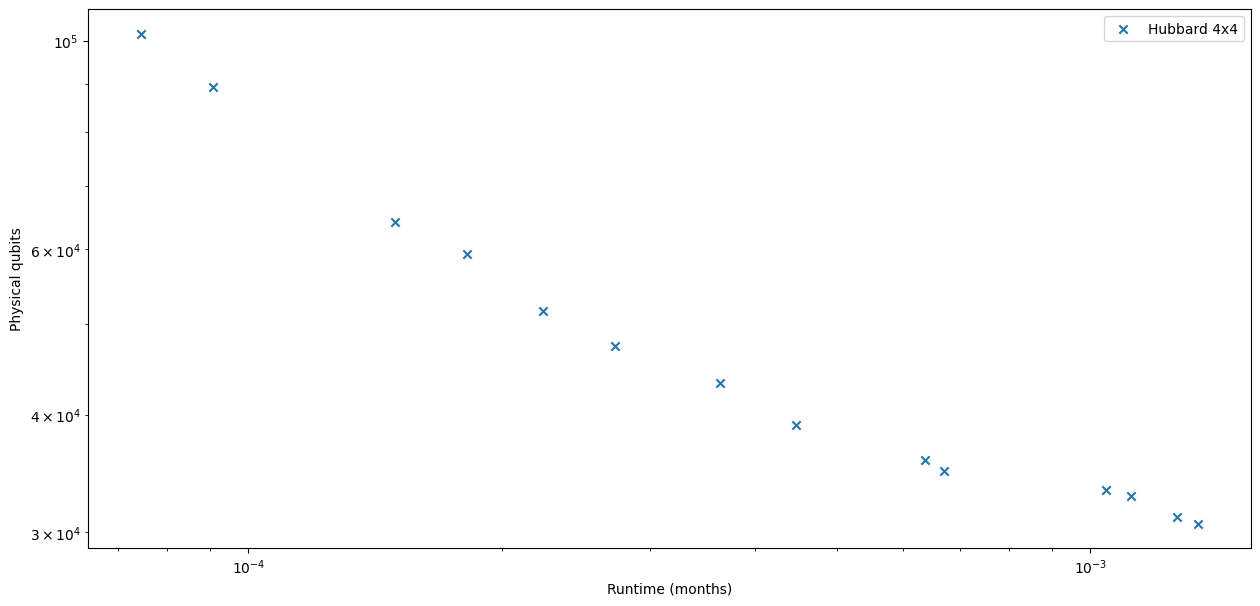

In [7]:
plot_estimates([estimates], runtime_unit="months", figsize=(15, 7))